## 1) Install Required Packages

Install the libraries needed for data loading, preprocessing, modeling, evaluation, and explainability

In [1]:
!pip -q install numpy pandas scikit-learn matplotlib seaborn statsbombpy mplsoccer shap tqdm pyarrow


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 2) Import Libraries

Import all dependencies used in the xG pipeline including StatsBomb data access, modeling utilities, metrics, plotting, and SHAP

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsbombpy import sb
from mplsoccer import Pitch
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve
import shap
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

ASSETS_DIR = Path('assets/images')
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')

/Users/tymek/Documents/cv_projects/xg_project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3) Load Match Event Data

Load FIFA World Cup 2022 and UEFA Euro 2024 from StatsBomb, merge match events, and keep only shot events for xG modeling

### Caching Strategy

The data loading cell implements a parquet-based cache to avoid redundant API calls. On the first run, StatsBomb data is fetched from the API and saved to `data/shots_cache.parquet`. Subsequent runs load from disk in seconds. To refresh data, delete the cache file and re-run the cell.


In [3]:
CACHE_PATH = Path('data/shots_cache.parquet')

if CACHE_PATH.exists():
    # Load from local cache — skips API entirely
    shots = pd.read_parquet(CACHE_PATH)
    print(f"Loaded from cache: {len(shots)} shots")
else:
    # First run: fetch from StatsBomb API and cache to disk
    Path('data').mkdir(exist_ok=True)
    
    competitions = sb.competitions()
    # Filter for men's competitions only
    competitions = competitions[competitions['competition_gender'] == 'male']
    tournaments = [(row['competition_id'], row['season_id']) for _, row in competitions.iterrows()]
    print(f"Loading {len(tournaments)} men's competitions from StatsBomb")
    
    all_matches = []
    for competition_id, season_id in tqdm(tournaments, desc='Loading competitions'):
        matches = sb.matches(competition_id=competition_id, season_id=season_id)
        all_matches.append(matches)
    
    matches = pd.concat(all_matches, ignore_index=True)
    match_ids = matches['match_id'].drop_duplicates().tolist()
    
    events_list = []
    failed = []
    for match_id in tqdm(match_ids, desc='Fetching matches'):
        try:
            match_events = sb.events(match_id=match_id, split=False, flatten_attrs=True)
            match_events['match_id'] = match_id
            events_list.append(match_events)
        except Exception as e:
            failed.append(match_id)
            print(f"Failed: {match_id} — {e}")
    
    events = pd.concat(events_list, ignore_index=True)
    shots = events[events['type'] == 'Shot'].copy()
    
    shots.to_parquet(CACHE_PATH, index=False)
    print(f"Fetched and cached: {len(shots)} shots")
    if failed:
        print(f"Failed match IDs: {failed}")


Loaded from cache: 73874 shots


## 4) Prepare Features and Target

Create shot geometry features, clean contextual fields with Unknown for missing values, and build the binary goal target where 1 means Goal and 0 means No Goal

In [4]:
# Split StatsBomb shot location arrays into explicit x and y coordinates
shots['x'] = shots['location'].apply(lambda v: v[0] if hasattr(v, '__len__') and len(v) >= 2 else np.nan)
shots['y'] = shots['location'].apply(lambda v: v[1] if hasattr(v, '__len__') and len(v) >= 2 else np.nan)

# Define standard StatsBomb pitch and goal geometry for shot feature math
goal_x = 120.0
goal_y = 40.0
goal_width = 8.0
left_post_y = goal_y - goal_width / 2
right_post_y = goal_y + goal_width / 2

# Compute Euclidean distance from shot location to center of goal
shots['shot_distance'] = np.sqrt((goal_x - shots['x']) ** 2 + (goal_y - shots['y']) ** 2)

# Compute visible shooting angle using vectors to left and right goalposts
left_angle = np.arctan2(left_post_y - shots['y'], goal_x - shots['x'])
right_angle = np.arctan2(right_post_y - shots['y'], goal_x - shots['x'])
shots['shot_angle'] = np.abs(right_angle - left_angle)
shots.loc[shots['shot_angle'] > np.pi, 'shot_angle'] = 2 * np.pi - shots.loc[shots['shot_angle'] > np.pi, 'shot_angle']

# Extract categorical and contextual shot features from event payload fields
shots['body_part'] = shots['shot_body_part'].fillna('Unknown').astype(str)
shots['play_pattern'] = shots['play_pattern'].fillna('Unknown').astype(str)
shots['shot_technique'] = shots['shot_technique'].fillna('Unknown').astype(str)
shots['under_pressure'] = shots['under_pressure'].fillna(False).astype(int)

# Binary contextual features — convert to int (None/NaN becomes 0)
shots['is_deflected'] = shots['shot_deflected'].notna().astype(int)
shots['is_one_on_one'] = shots['shot_one_on_one'].notna().astype(int)
shots['is_aerial_won'] = shots['shot_aerial_won'].notna().astype(int)

# First time shot flag — already provided by StatsBomb
shots['is_first_time'] = shots['shot_first_time'].notna().astype(int)

# Number of defenders in freeze frame blocking the shot line
def count_defenders_in_cone(row):
    try:
        ff = row.get('shot_freeze_frame', [])
        if not isinstance(ff, list) or len(ff) == 0:
            return 0
        sx, sy = row['x'], row['y']
        count = 0
        for player in ff:
            if player.get('teammate', True):
                continue
            px, py = player['location']
            # check if defender is between shot and goal (rough cone)
            if px > sx and abs(py - sy) < (px - sx) * 0.5:
                count += 1
        return count
    except Exception:
        return 0

shots['defenders_in_cone'] = shots.apply(count_defenders_in_cone, axis=1)

# Create binary target: 1 if outcome is Goal, otherwise 0
shots['is_goal'] = (shots['shot_outcome'].fillna('Unknown').astype(str) == 'Goal').astype(int)

# Drop only rows with missing x, y, shot_distance, or shot_angle (required geometric features)
model_data = shots[['x', 'y', 'shot_distance', 'shot_angle', 'under_pressure', 'is_first_time', 
                     'is_deflected', 'is_one_on_one', 'is_aerial_won', 'defenders_in_cone', 
                     'body_part', 'shot_technique', 'is_goal']].dropna(subset=['x', 'y', 'shot_distance', 'shot_angle']).copy()

print(f"Created {len(model_data)} valid shot records for modeling (from {len(shots)} total shots)")


Created 73874 valid shot records for modeling (from 73874 total shots)


## 5) Train and Evaluate the Random Forest xG Model

One hot encode categorical features, train Random Forest, compute xG as predicted goal probability, and evaluate with probabilistic metrics plus ROC and PR curves

,Model,ROC-AUC,Log Loss,Brier Score,PR-AUC
0,Random Forest,0.8194,0.4981,0.1624,0.4501


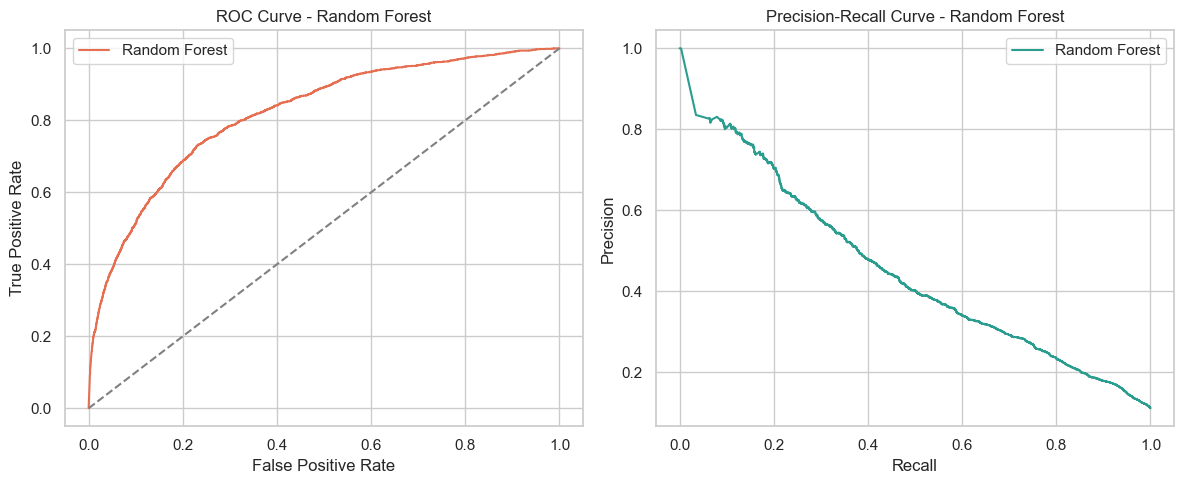

In [5]:
X_raw = model_data[['shot_distance', 'shot_angle', 'under_pressure', 'is_first_time', 
                     'is_deflected', 'is_one_on_one', 'is_aerial_won', 'defenders_in_cone', 
                     'body_part', 'shot_technique']].copy()
y = model_data['is_goal'].copy()

# One-hot encode categorical columns
X = pd.get_dummies(X_raw, columns=['body_part', 'shot_technique'])

# Split data into train and test sets for unbiased model evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Configure Random Forest classifier with class weighting to handle goal/non-goal imbalance
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# xG is modeled as the probability of class 1 (Goal)
rf_xg = rf_model.predict_proba(X_test)[:, 1]

# Summarize probabilistic model quality metrics in a compact table
metrics_df = pd.DataFrame({
    'Model': ['Random Forest'],
    'ROC-AUC': [roc_auc_score(y_test, rf_xg)],
    'Log Loss': [log_loss(y_test, rf_xg, labels=[0, 1])],
    'Brier Score': [brier_score_loss(y_test, rf_xg)],
    'PR-AUC': [average_precision_score(y_test, rf_xg)]
}).round(4)
display(metrics_df)

# Build ROC and Precision-Recall curves to inspect ranking quality and class-imbalance behavior
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_xg)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, rf_xg)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr_rf, tpr_rf, color='#e76f51', label='Random Forest')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('ROC Curve - Random Forest')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

axes[1].plot(rec_rf, prec_rf, color='#2a9d8f', label='Random Forest')
axes[1].set_title('Precision-Recall Curve - Random Forest')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
fig.savefig(ASSETS_DIR / 'roc_pr_curves.png', dpi=220, bbox_inches='tight')
plt.show()


## 5.1) Baseline Models Benchmark

Compare three models to understand how features and model class affect xG prediction:
1. **Logistic Regression** on all features (linear baseline to assess feature separability)
2. **Geometry-Only Random Forest** using only shot_distance and shot_angle (isolates geometry contribution)
3. **Full Random Forest** with all features (production model)

Evaluate all three on identical test data to quantify feature lift and probability calibration quality.

,Model,ROC-AUC,Log Loss,Brier Score,PR-AUC
0,Logistic Regression,0.8137,0.5343,0.1751,0.4042
1,Geometry-Only RF,0.7671,0.5318,0.1788,0.3600
2,Full RF,0.8194,0.4981,0.1624,0.4501


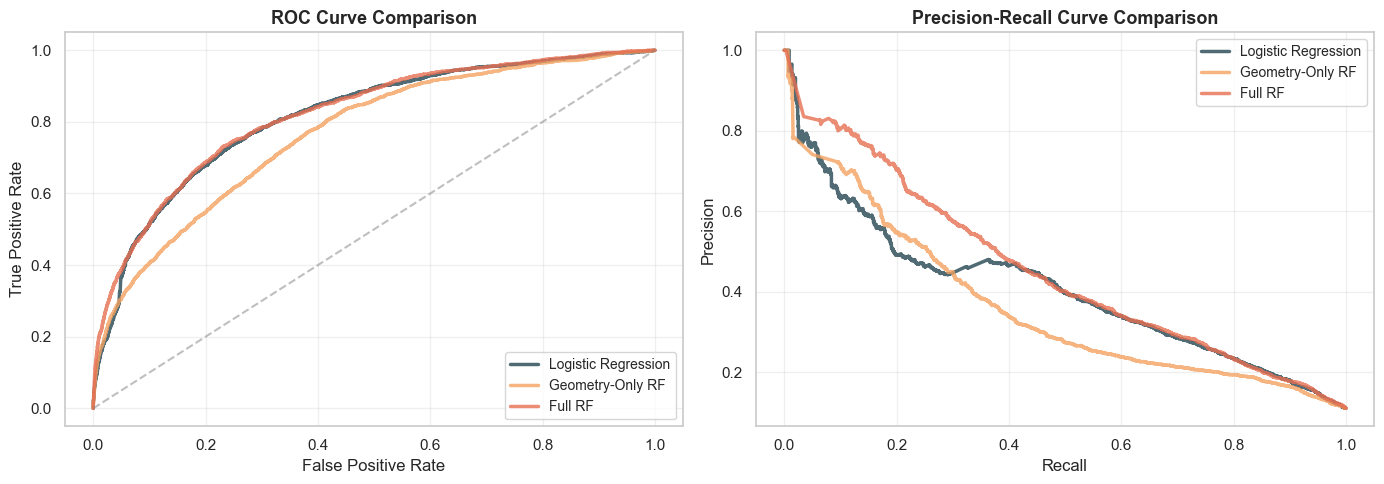

In [6]:
from sklearn.linear_model import LogisticRegression

# Geometry-only feature set: just shot_distance and shot_angle
X_geo = X_raw[['shot_distance', 'shot_angle']].copy()
X_geo = pd.get_dummies(X_geo)

# One-hot encode for consistency with full model
X_geo_train, X_geo_test = X_geo.loc[X_train.index], X_geo.loc[X_test.index]

# Baseline 1: Logistic Regression on full feature set
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
lr_model.fit(X_train, y_train)
lr_xg = lr_model.predict_proba(X_test)[:, 1]

# Baseline 2: Geometry-only Random Forest (same RF hyperparams, only distance + angle)
geo_rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
geo_rf_model.fit(X_geo_train, y_train)
geo_rf_xg = geo_rf_model.predict_proba(X_geo_test)[:, 1]

# Compare all three models
all_models_metrics = pd.DataFrame({
    'Model': ['Logistic Regression', 'Geometry-Only RF', 'Full RF'],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_xg),
        roc_auc_score(y_test, geo_rf_xg),
        roc_auc_score(y_test, rf_xg)
    ],
    'Log Loss': [
        log_loss(y_test, lr_xg, labels=[0, 1]),
        log_loss(y_test, geo_rf_xg, labels=[0, 1]),
        log_loss(y_test, rf_xg, labels=[0, 1])
    ],
    'Brier Score': [
        brier_score_loss(y_test, lr_xg),
        brier_score_loss(y_test, geo_rf_xg),
        brier_score_loss(y_test, rf_xg)
    ],
    'PR-AUC': [
        average_precision_score(y_test, lr_xg),
        average_precision_score(y_test, geo_rf_xg),
        average_precision_score(y_test, rf_xg)
    ]
}).round(4)
display(all_models_metrics)

# Compute ROC and PR curves for all three models
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_xg)
prec_lr, rec_lr, _ = precision_recall_curve(y_test, lr_xg)

fpr_geo_rf, tpr_geo_rf, _ = roc_curve(y_test, geo_rf_xg)
prec_geo_rf, rec_geo_rf, _ = precision_recall_curve(y_test, geo_rf_xg)

# Create overlaid comparison figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve comparison
axes[0].plot(fpr_lr, tpr_lr, color='#264653', linewidth=2.5, label='Logistic Regression', alpha=0.8)
axes[0].plot(fpr_geo_rf, tpr_geo_rf, color='#f4a261', linewidth=2.5, label='Geometry-Only RF', alpha=0.8)
axes[0].plot(fpr_rf, tpr_rf, color='#e76f51', linewidth=2.5, label='Full RF', alpha=0.8)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.5)
axes[0].set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

# PR curve comparison
axes[1].plot(rec_lr, prec_lr, color='#264653', linewidth=2.5, label='Logistic Regression', alpha=0.8)
axes[1].plot(rec_geo_rf, prec_geo_rf, color='#f4a261', linewidth=2.5, label='Geometry-Only RF', alpha=0.8)
axes[1].plot(rec_rf, prec_rf, color='#e76f51', linewidth=2.5, label='Full RF', alpha=0.8)
axes[1].set_title('Precision-Recall Curve Comparison', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(ASSETS_DIR / 'benchmark_curves.png', dpi=220, bbox_inches='tight')
plt.show()

## 5.2) Calibration Analysis

Assess probability calibration: are predicted probabilities honest reflections of true outcome frequencies? For xG to be trusted as a metric, if the model predicts 10 shots at 0.30 probability each, roughly 3 should result in goals. Plot calibration curves (reliability diagrams) showing the alignment between predicted and actual frequencies. Expected Calibration Error (ECE) quantifies this misalignment numerically: lower ECE indicates better calibration. All three models here are miscalibrated—they lie systematically below the diagonal in the mid-probability range, indicating overconfidence. ECE values of 0.28–0.32 represent poor absolute calibration. The Full RF model performs best among the three but remains notably miscalibrated; this is expected behavior for tree-based classifiers on heavily imbalanced datasets. Post-hoc calibration methods (Platt scaling, isotonic regression) can help if precise probability estimates are critical for downstream applications.

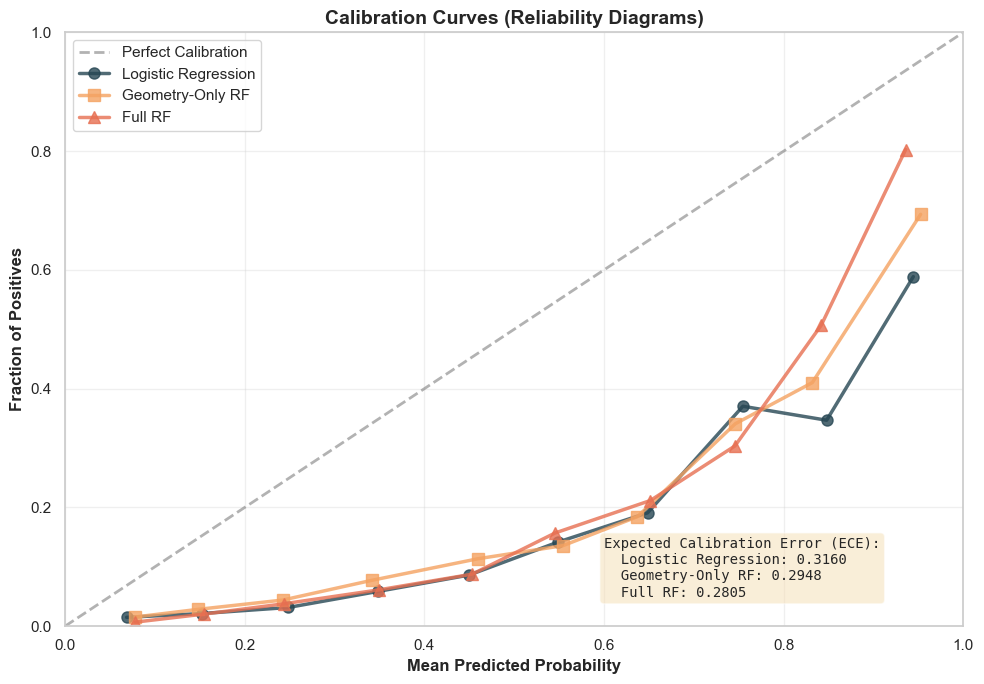

,Model,ECE
0,Logistic Regression,0.3160
1,Geometry-Only RF,0.2948
2,Full RF,0.2805


In [7]:
from sklearn.calibration import calibration_curve

# Compute calibration curves for all three models
n_bins = 10

# Logistic Regression calibration
prob_true_lr, prob_pred_lr = calibration_curve(y_test, lr_xg, n_bins=n_bins, strategy='uniform')

# Geometry-Only RF calibration
prob_true_geo_rf, prob_pred_geo_rf = calibration_curve(y_test, geo_rf_xg, n_bins=n_bins, strategy='uniform')

# Full RF calibration
prob_true_rf, prob_pred_rf = calibration_curve(y_test, rf_xg, n_bins=n_bins, strategy='uniform')

# Calculate Expected Calibration Error (ECE) for each model
# ECE = mean absolute difference between predicted probability and fraction of positives in each bin
ece_lr = np.mean(np.abs(prob_pred_lr - prob_true_lr))
ece_geo_rf = np.mean(np.abs(prob_pred_geo_rf - prob_true_geo_rf))
ece_rf = np.mean(np.abs(prob_pred_rf - prob_true_rf))

# Create calibration plot
fig, ax = plt.subplots(figsize=(10, 7))

# Plot diagonal reference line (perfect calibration)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=2, alpha=0.6, label='Perfect Calibration')

# Plot calibration curves
ax.plot(prob_pred_lr, prob_true_lr, marker='o', linewidth=2.5, markersize=8, 
        color='#264653', label='Logistic Regression', alpha=0.8)
ax.plot(prob_pred_geo_rf, prob_true_geo_rf, marker='s', linewidth=2.5, markersize=8,
        color='#f4a261', label='Geometry-Only RF', alpha=0.8)
ax.plot(prob_pred_rf, prob_true_rf, marker='^', linewidth=2.5, markersize=8,
        color='#e76f51', label='Full RF', alpha=0.8)

ax.set_xlabel('Mean Predicted Probability', fontsize=12, fontweight='bold')
ax.set_ylabel('Fraction of Positives', fontsize=12, fontweight='bold')
ax.set_title('Calibration Curves (Reliability Diagrams)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Add text box with ECE values
ece_text = f'Expected Calibration Error (ECE):\n'
ece_text += f'  Logistic Regression: {ece_lr:.4f}\n'
ece_text += f'  Geometry-Only RF: {ece_geo_rf:.4f}\n'
ece_text += f'  Full RF: {ece_rf:.4f}'
ax.text(0.6, 0.15, ece_text, fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        verticalalignment='top', family='monospace')

plt.tight_layout()
fig.savefig(ASSETS_DIR / 'calibration_curve.png', dpi=220, bbox_inches='tight')
plt.show()

# Create summary table of ECE values
ece_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Geometry-Only RF', 'Full RF'],
    'ECE': [ece_lr, ece_geo_rf, ece_rf]
}).round(4)
display(ece_df)

## 6) Model Comparison, Calibration, Visualizations, and Explainability

Following the baseline models benchmark in Section 5.1, we now visualize how contextual features lift prediction quality beyond geometry alone. Calibration analysis in Section 5.2 ensures the predicted probabilities align with true outcome frequencies. Feature importance plots identify the highest-leverage features, shot maps distribute predictions spatially, and SHAP values explain individual shot predictions.

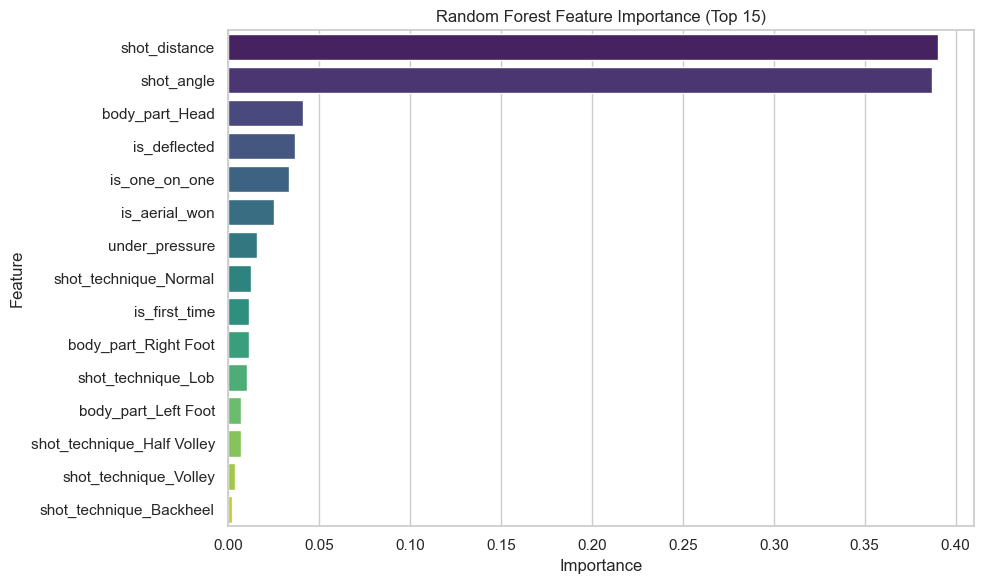

In [8]:
# Rank and visualize the most influential engineered features in the Random Forest model
feature_names = X_train.columns
feature_importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.head(15).values, y=feature_importance.head(15).index, palette='viridis')
plt.title('Random Forest Feature Importance (Top 15)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(ASSETS_DIR / 'feature_importance.png', dpi=220, bbox_inches='tight')
plt.show()

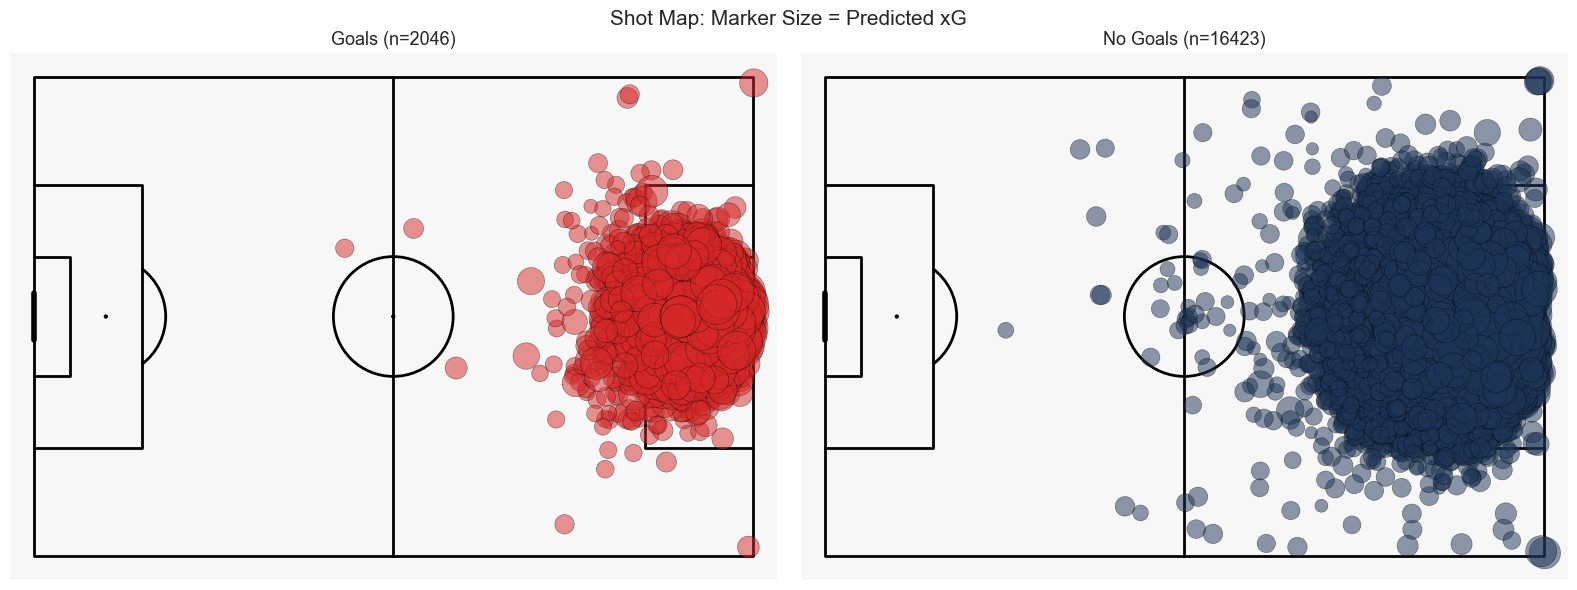

In [9]:
# Build plotting table with location, ground truth, and predicted xG
plot_df = X_test.copy()
plot_df['is_goal'] = y_test.values
plot_df['xg'] = rf_xg
plot_df['x'] = model_data.loc[plot_df.index, 'x']
plot_df['y'] = model_data.loc[plot_df.index, 'y']

# Plot all shots split into goals vs non-goals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
pitch = Pitch(pitch_type='statsbomb', pitch_color='#f7f7f7', line_color='black')

for ax, (label, subset, color) in zip(axes, [
    ('Goals', plot_df[plot_df['is_goal'] == 1], '#d62828'),
    ('No Goals', plot_df[plot_df['is_goal'] == 0], '#1d3557')
]):
    pitch.draw(ax=ax)
    pitch.scatter(
        subset['x'], subset['y'],
        s=30 + 900 * subset['xg'],
        c=color,
        edgecolors='black',
        linewidth=0.4,
        alpha=0.5,
        ax=ax
    )
    ax.set_title(f'{label} (n={len(subset)})', fontsize=13)

fig.suptitle('Shot Map: Marker Size = Predicted xG', fontsize=15)
plt.tight_layout()
fig.savefig(ASSETS_DIR / 'shot_map_xg.png', dpi=220, bbox_inches='tight')
plt.show()


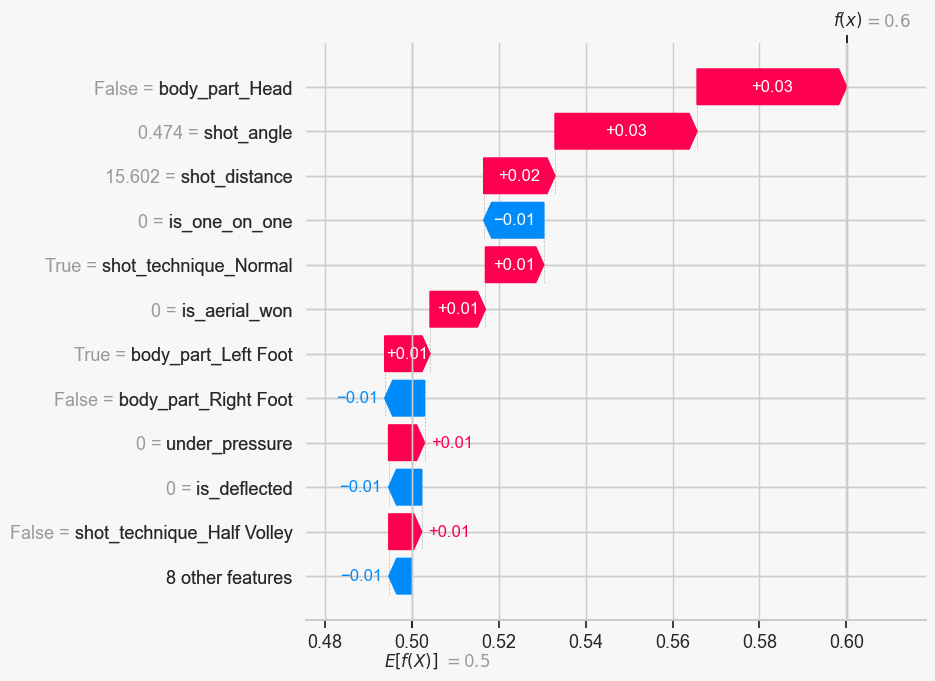

In [10]:
# Explain one goal prediction with xG closest to 0.60 using SHAP waterfall values
feature_names = X_train.columns
target_xg = 0.60
goal_idx = y_test[y_test == 1].index
goal_scores = pd.Series(rf_xg, index=X_test.index).loc[goal_idx]
selected_index = (goal_scores - target_xg).abs().idxmin()
shot_index = int(X_test.index.get_loc(selected_index))

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shot_sv = shap_values[1][shot_index]
    base_value = explainer.expected_value[1]
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    shot_sv = shap_values[shot_index, :, 1]
    base_value = explainer.expected_value[1]
else:
    shot_sv = shap_values[shot_index]
    base_value = explainer.expected_value

shot_explanation = shap.Explanation(
    values=shot_sv,
    base_values=base_value,
    data=X_test.iloc[shot_index].values,
    feature_names=feature_names
)
shap.plots.waterfall(shot_explanation, max_display=12, show=False)
fig = plt.gcf()
fig.patch.set_facecolor('#f7f7f7')
for ax in fig.axes:
    ax.set_facecolor('#f7f7f7')
fig.savefig(
    ASSETS_DIR / 'shap_waterfall.png',
    dpi=220,
    bbox_inches='tight',
    facecolor=fig.get_facecolor(),
    edgecolor='none'
 )
plt.show()